Visualisation des résultats sur l'instance data_temp.test

# Experiences sur les résultats obtenues avec le modèle d'ordonnancement

In [6]:
%load_ext autoreload
%autoreload 2

import gurobipy as gp
from gurobipy import GRB

from matplotlib import pyplot as plt

from first_model import Instance, Solution, Model
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# I. Visualisation du graphe de précédence des opérations pour chaque Job:

In [7]:
res = read_file("../data/data_temp.test")
instance = Instance()
instance.from_dictionary(res)

In [8]:
print(instance)


 ===== Start of Instance: =====
Number of jobs: 2
Number of professions: 3
Number of tasks per profession: [2. 4. 1.]
Max number of operations per Jobs: 5
Total number of tasks: 7
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 2}
Worker levels: shape=(3, 3)
 [[2. 2. 1.]
 [4. 3. 2.]
 [1. 2. 1.]]
Job difficulties: shape= (2,)
[2. 2.]
Task difficulties: shape= (7,)
[1 2 3 3 2 2 2]
Task processing times: shape= (7, 3)
[[ 50. 100.  -1.]
 [ 15.  21.  -1.]
 [  5.   8.   2.]
 [  4.   6.   2.]
 [  5.  10.   2.]
 [  4.  11.   2.]
 [ 10.  20.   2.]]
Jobs structure: len= 2
Job 0 : 	O_(0,0) = 0 	O_(0,1) = 2 	O_(0,2) = 6 	O_(0,3) = 2 
Job 1 : 	O_(1,0) = 3 	O_(1,1) = 1 	O_(1,2) = 6 	O_(1,3) = 4 	O_(1,4) = 4 

Precedence constraints: shape= (2, 5, 5)
[[[0. 1. 0. 0. 0.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 [[0. 1. 0. 0. 0.]
  [0. 0. 1. 0. 0.]
  [0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 1.]
  [0. 0. 0. 0. 0.]]]

 ===== End 

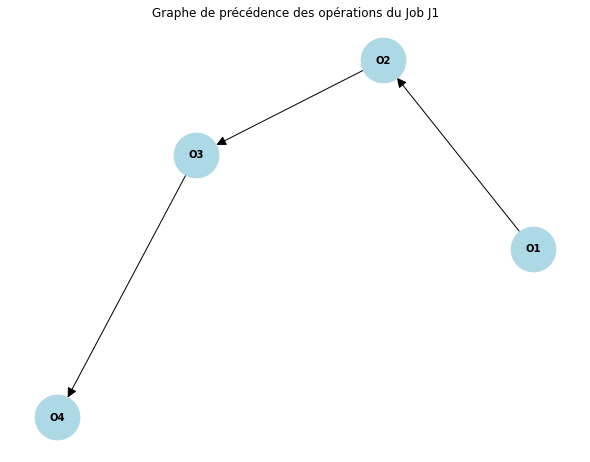

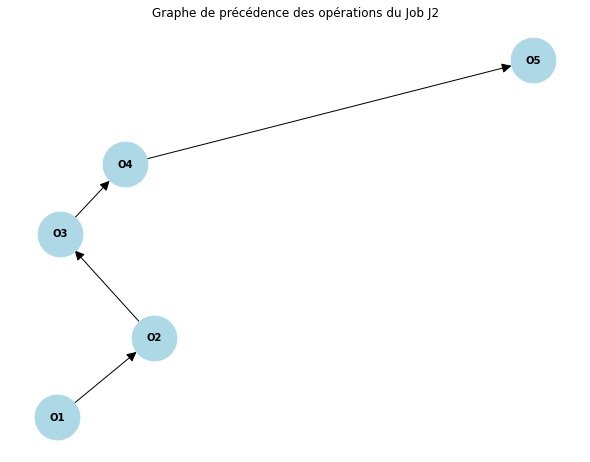

In [9]:
plot_precedence_graph(instance)

---

# II. Analyses de quelque résultats du problème d'odonnancement - approche par la programmation linéaire mixte MILP:

# II.A Min makespan seulement

### 1) Résolution du problème d'ordonnancement avec Gurobi

In [35]:
model = Model(instance)
s = model.solve(objective="makespan",weight=[0, 0, 0], priority=[0, 0, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 86.0
ici ->  1
nObjectives 1
nSolutions 7


### 2) Visualisation du diagramme de Gantt

#### 2.1) Visualisation par opération

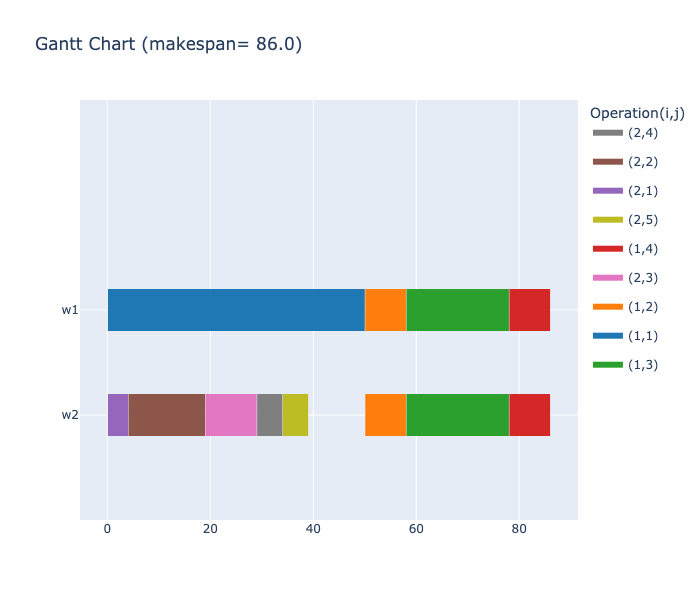

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.1,50.0,50.0,50.0,"(1,1)",J1,alone,2.0,1,0.0,0.0
1,w1,50.1,58.0,58.0,8.0,"(1,2)",J1,learning (apprentice),2.0,3,2.0,1.0
2,w1,58.1,78.0,78.0,20.0,"(1,3)",J1,learning (apprentice),1.0,2,6.0,2.0
3,w1,78.1,86.0,86.0,8.0,"(1,4)",J1,learning (apprentice),2.0,3,2.0,1.0
4,w2,0.1,4.0,4.0,4.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
5,w2,4.1,19.0,19.0,15.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
6,w2,19.1,29.0,29.0,10.0,"(2,3)",J2,alone,2.0,2,6.0,2.0
7,w2,29.1,34.0,34.0,5.0,"(2,4)",J2,alone,3.0,2,4.0,1.0
8,w2,34.1,39.0,39.0,5.0,"(2,5)",J2,alone,3.0,2,4.0,1.0
9,w2,50.1,58.0,58.0,8.0,"(1,2)",J1,learning (tutor),3.0,3,2.0,1.0


In [36]:
gantt_chart(s, instance, color=1, render="notebook", separate_little=True)

#### 2.2) Visualisation par Job

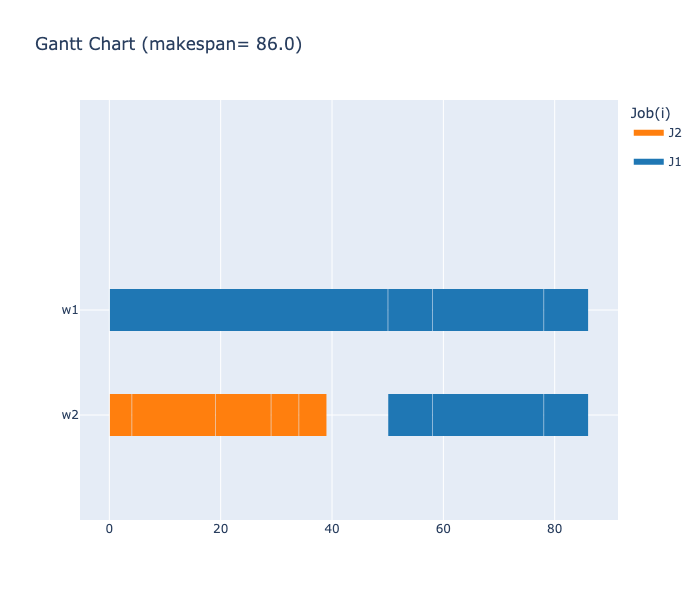

In [37]:
df = gantt_chart(s, instance, color=2, render="notebook", separate_little=True)

#### 2.3) Visualisationn par mode d'éxécution (seul, en apprentissage, collaboration ou solo sans level)

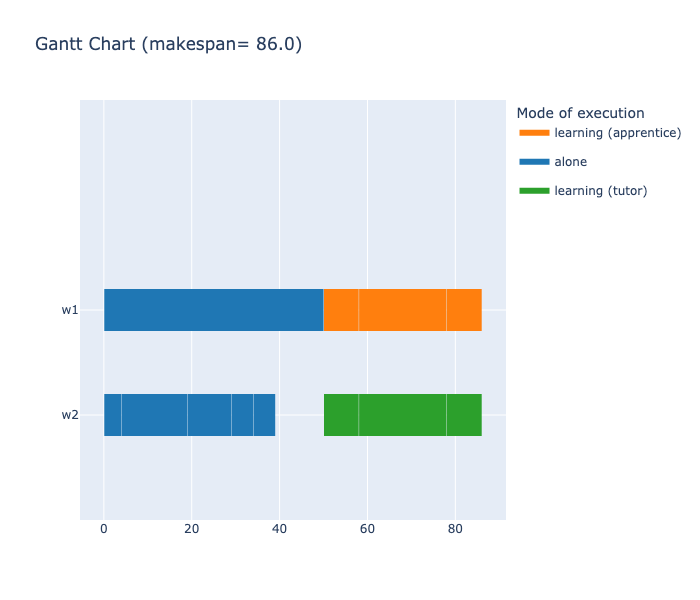

In [38]:
df = gantt_chart(s, instance, color=3, render="notebook", separate_little=True)

- On peut voir que malgré que l'on minimise le makespan on a quand meme des taches fait en apprentissage car un opérateur qui commence la première opération d'un job est affecté à tous le job.
- Plus rapide de donner la tache de temps 50 a un worker puis l'assister sur la fin du job (car il n'a pas le niveau pour finir le job) plutot que le worker 2 fasse le job entie
- On voit que $w_2$ à le niveau pour faire $J_1$, mais plus rapide de laissr $w_1$ avancer le debut de $J_1$ pendant que $w_2$ fait $J_2$ puis $w_1$ assiste (donc plus de temps) $w_2$ sur la fin de $J_1$ plutot que $w_2$ fasse $J_1$ entierement.
- Si un opérateur n'est pas forcé de faire toutes les opération du Job auquelle il est affecté on aurait eu un autre scénario où peut être $w_2$ aurait fini $J_1$ seul

Check si on a bien que :
- tache fait en solo alors l'operateur à le niveau requis sur cette tache
- tache fait en tant que tuteur alors l'operateur à le niveau requis sur cette tache
- tache fait en tant qu'apprenti alors l'operateur n'a pas le niveau requis sur cette tache
- tache fait en collaboration alors l'opérateur à le niveau requis sur cette tache

À faire :
- compléxifier la fonctiion de vérification pour voir si tache en collab est bien fait à 2, ainsi qu'en teaching. la meme tache est fait avec tuteur et apprenti etc..

In [39]:
check_df(df)

True

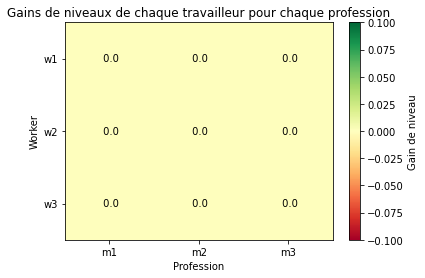

In [40]:
# plot_levels_workers(s, instance)
resume_levels_workers(s, instance)

- Quand on minimise le makespan seulement on force pas les variables lié aux skills à être le plus grand possible. Les contraintes associé aux skills donne un intervalle de valeurs réalisable poue les skills des workers, et le modèle choisit n'importe quelle valeurs dans cet intervalle pour les skills des workers

# II.B Max skill, puis Min Makespan 
(ce cache une opt. lexicographique skills puis makespan)

In [16]:
s = model.solve(objective="skill",weight=[0, 0, 0], priority=[0, 0, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0001e-06
ici ->  3
nObjectives 3
nSolutions 7


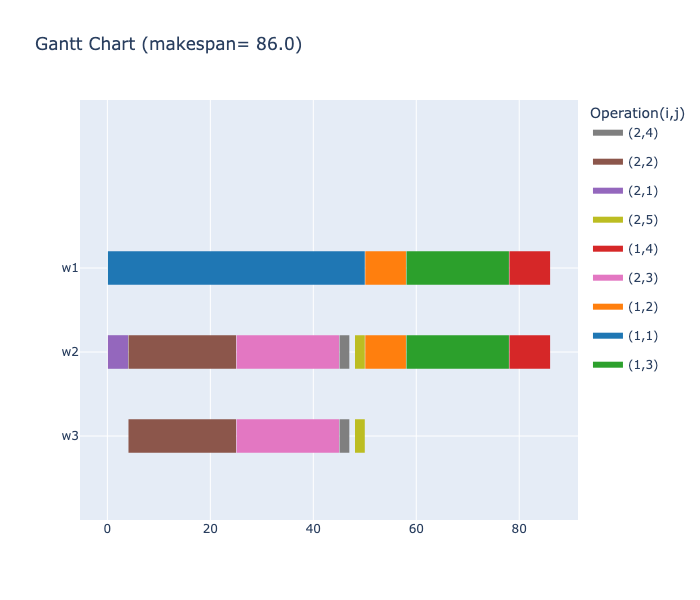

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.1,50.0,50.0,50.0,"(1,1)",J1,alone,2.0,1,0.0,0.0
1,w1,50.1,58.0,58.0,8.0,"(1,2)",J1,learning (apprentice),2.0,3,2.0,1.0
2,w1,58.1,78.0,78.0,20.0,"(1,3)",J1,learning (apprentice),1.0,2,6.0,2.0
3,w1,78.1,86.0,86.0,8.0,"(1,4)",J1,learning (apprentice),2.0,3,2.0,1.0
4,w2,0.1,4.0,4.0,4.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
5,w2,4.1,25.0,25.0,21.0,"(2,2)",J2,learning (tutor),4.0,2,1.0,0.0
6,w2,25.1,45.0,45.0,20.0,"(2,3)",J2,learning (tutor),2.0,2,6.0,2.0
7,w2,45.1,47.0,47.0,2.0,"(2,4)",J2,collaboratively,3.0,2,4.0,1.0
8,w2,48.1,50.0,50.0,2.0,"(2,5)",J2,collaboratively,3.0,2,4.0,1.0
9,w2,50.1,58.0,58.0,8.0,"(1,2)",J1,learning (tutor),3.0,3,2.0,1.0


In [17]:
gantt_chart(s, instance, color=1, render="notebook", separate_little=True)

- Pour cette instance la, on voit que 
    - $C_{max}$ = 86 pour Min Makespan seulement
    - $C_{max}$ = 86 pour Max skill puis Min Makespan

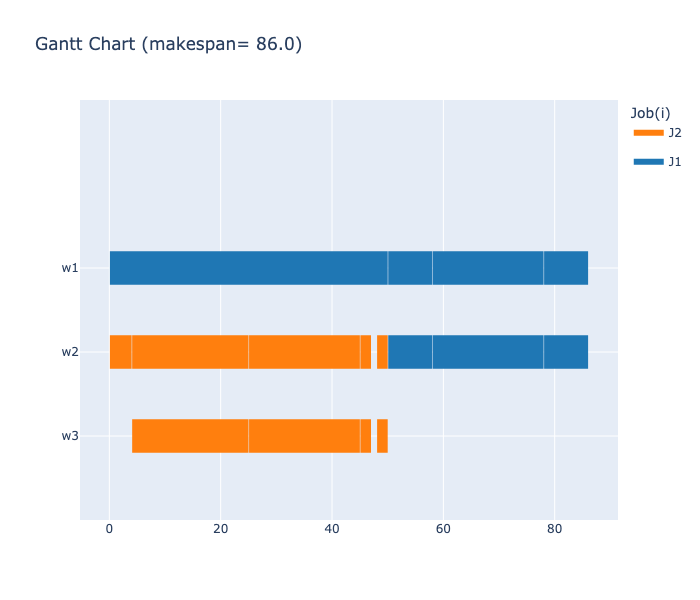

In [18]:
df = gantt_chart(s, instance, color=2, render="notebook", separate_little=True)

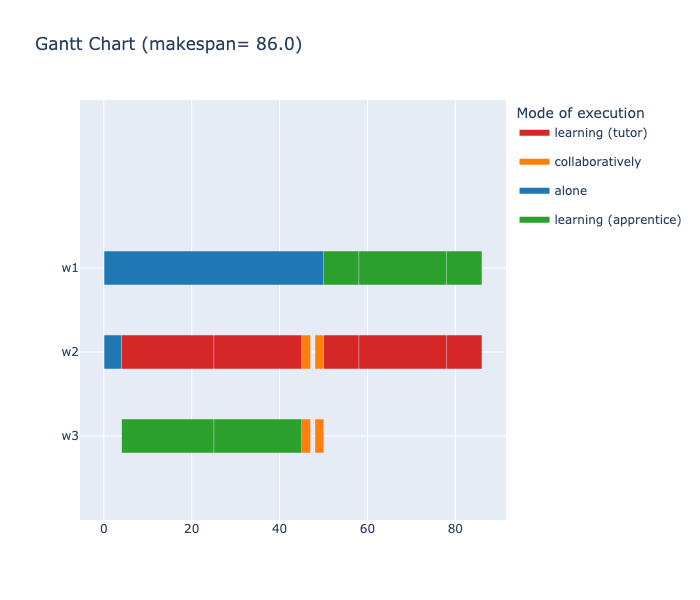

In [19]:
df = gantt_chart(s, instance, color=3, render="notebook", separate_little=True)

In [20]:
check_df(df)

True

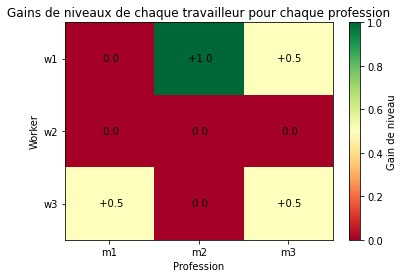

In [21]:
# plot_levels_workers(s, instance)
resume_levels_workers(s, instance)

- On peut voir avec cette heatmap la dynamique d'apprentissage sur chaque corps de métier des workers

# II.C Min Makespan puis max skill (lexicographic)

In [22]:
s = model.solve(objective="lexicographic",weight=[0, 0, 0], priority=[2,1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0001e-06
ici ->  4
nObjectives 4
nSolutions 10


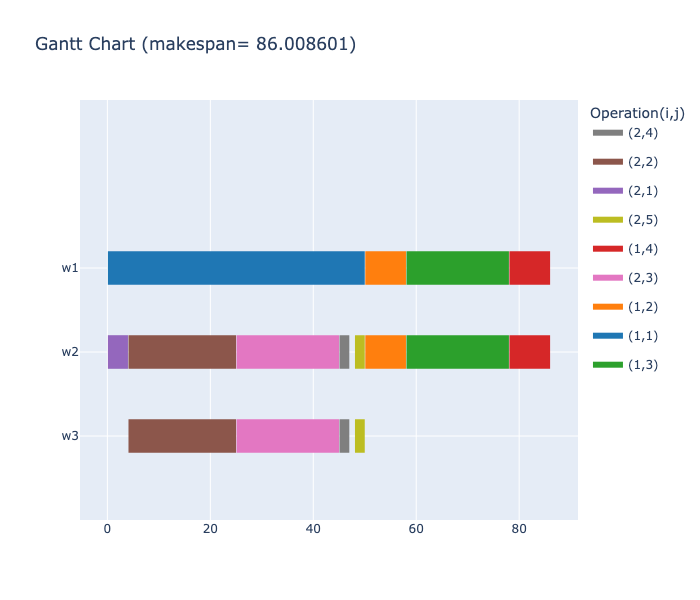

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.100000,50.000000,50.000000,50.0,"(1,1)",J1,alone,2.0,1,0.0,0.0
1,w1,50.108601,58.008601,58.008601,8.0,"(1,2)",J1,learning (apprentice),2.0,3,2.0,1.0
2,w1,58.108601,78.008601,78.008601,20.0,"(1,3)",J1,learning (apprentice),1.0,2,6.0,2.0
3,w1,78.108601,86.008601,86.008601,8.0,"(1,4)",J1,learning (apprentice),2.0,3,2.0,1.0
4,w2,0.100000,4.000000,4.000000,4.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
5,w2,4.100000,25.000000,25.000000,21.0,"(2,2)",J2,learning (tutor),4.0,2,1.0,0.0
6,w2,25.100000,45.000000,45.000000,20.0,"(2,3)",J2,learning (tutor),2.0,2,6.0,2.0
7,w2,45.100000,47.000000,47.000000,2.0,"(2,4)",J2,collaboratively,3.0,2,4.0,1.0
8,w2,48.100000,50.000000,50.000000,2.0,"(2,5)",J2,collaboratively,3.0,2,4.0,1.0
9,w2,50.108601,58.008601,58.008601,8.0,"(1,2)",J1,learning (tutor),3.0,3,2.0,1.0


In [23]:
gantt_chart(s, instance, color=1, render="notebook", separate_little=True)

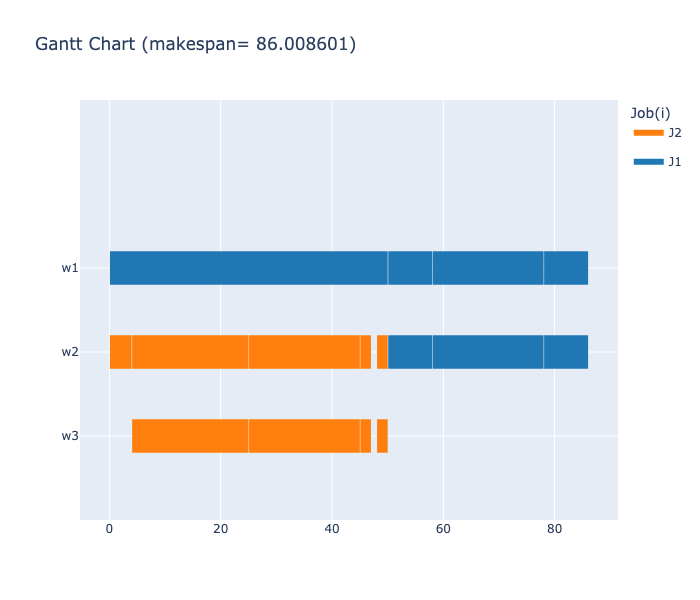

In [24]:
df = gantt_chart(s, instance, color=2, render="notebook", separate_little=True)

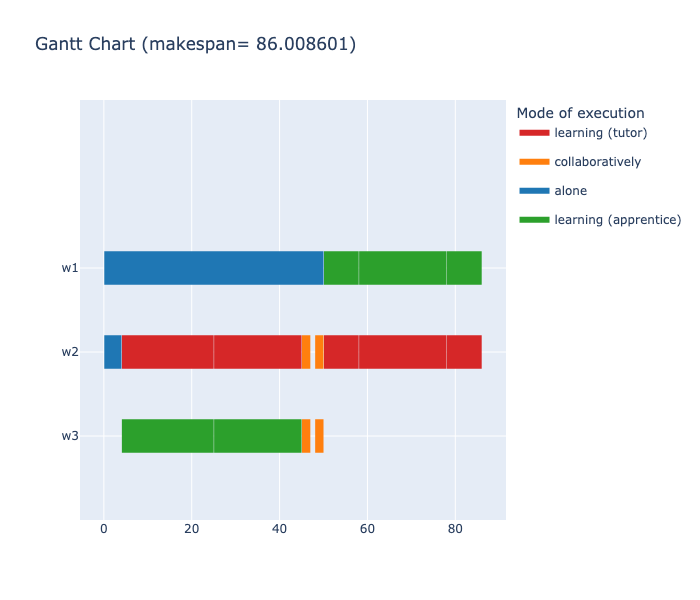

In [25]:
df = gantt_chart(s, instance, color=3, render="notebook", separate_little=True)

In [26]:
check_df(df)

True

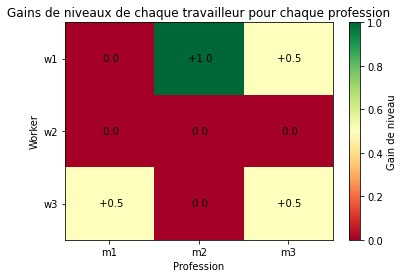

In [27]:
resume_levels_workers(s, instance)

# II.D Min charge cognitve

In [28]:
s = model.solve(objective="cognitive_load_total", weight=[0, 0, 0], priority=[0, 0, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 0.0
ici ->  1
nObjectives 1
nSolutions 1


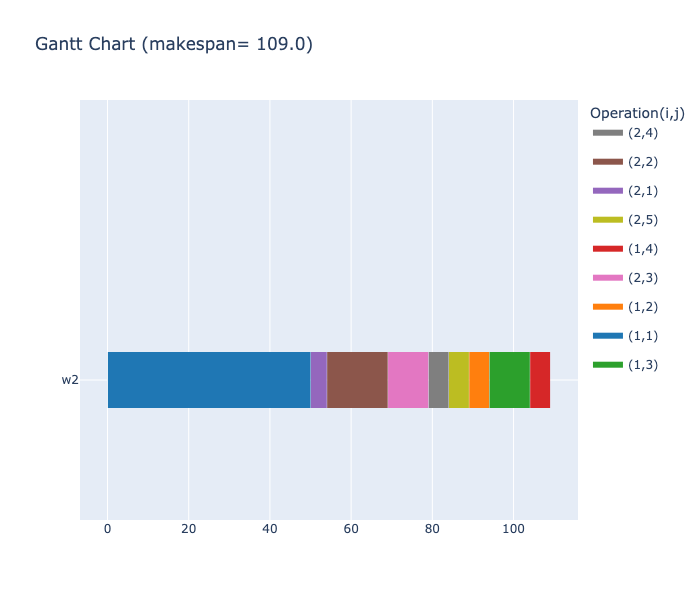

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w2,0.1,50.0,50.0,50.0,"(1,1)",J1,alone,4.0,1,0.0,0.0
1,w2,50.1,54.0,54.0,4.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
2,w2,54.1,69.0,69.0,15.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
3,w2,69.1,79.0,79.0,10.0,"(2,3)",J2,alone,2.0,2,6.0,2.0
4,w2,79.1,84.0,84.0,5.0,"(2,4)",J2,alone,3.0,2,4.0,1.0
5,w2,84.1,89.0,89.0,5.0,"(2,5)",J2,alone,3.0,2,4.0,1.0
6,w2,89.1,94.0,94.0,5.0,"(1,2)",J1,alone,3.0,3,2.0,1.0
7,w2,94.1,104.0,104.0,10.0,"(1,3)",J1,alone,2.0,2,6.0,2.0
8,w2,104.1,109.0,109.0,5.0,"(1,4)",J1,alone,3.0,3,2.0,1.0


In [29]:
gantt_chart(s, instance, color=1, render="notebook", separate_little=True)

- Il y a des taches qui ne sont pas faisable seul par les autres workers, comme on minimise la charge cognitif, les faire faire la tache demandera que $w_2$ l'assiste et fera augmenter sa charge cognitif, donc préfere faire la tache seul pour minimiser sa charge cognitif.

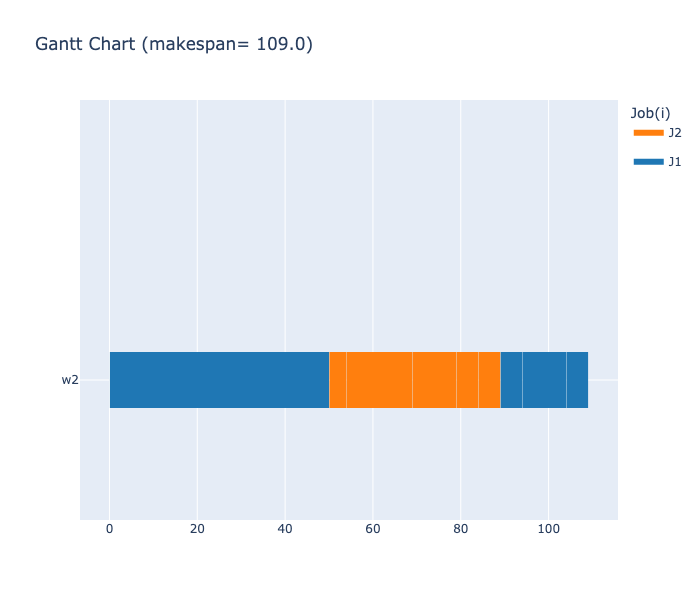

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w2,0.1,50.0,50.0,50.0,"(1,1)",J1,alone,4.0,1,0.0,0.0
1,w2,50.1,54.0,54.0,4.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
2,w2,54.1,69.0,69.0,15.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
3,w2,69.1,79.0,79.0,10.0,"(2,3)",J2,alone,2.0,2,6.0,2.0
4,w2,79.1,84.0,84.0,5.0,"(2,4)",J2,alone,3.0,2,4.0,1.0
5,w2,84.1,89.0,89.0,5.0,"(2,5)",J2,alone,3.0,2,4.0,1.0
6,w2,89.1,94.0,94.0,5.0,"(1,2)",J1,alone,3.0,3,2.0,1.0
7,w2,94.1,104.0,104.0,10.0,"(1,3)",J1,alone,2.0,2,6.0,2.0
8,w2,104.1,109.0,109.0,5.0,"(1,4)",J1,alone,3.0,3,2.0,1.0


In [30]:
gantt_chart(s, instance, color=2, render="notebook", separate_little=True)

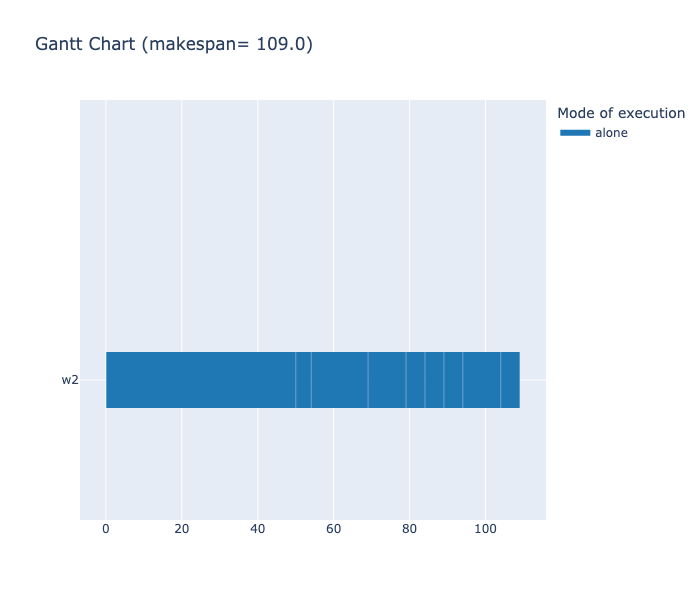

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w2,0.1,50.0,50.0,50.0,"(1,1)",J1,alone,4.0,1,0.0,0.0
1,w2,50.1,54.0,54.0,4.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
2,w2,54.1,69.0,69.0,15.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
3,w2,69.1,79.0,79.0,10.0,"(2,3)",J2,alone,2.0,2,6.0,2.0
4,w2,79.1,84.0,84.0,5.0,"(2,4)",J2,alone,3.0,2,4.0,1.0
5,w2,84.1,89.0,89.0,5.0,"(2,5)",J2,alone,3.0,2,4.0,1.0
6,w2,89.1,94.0,94.0,5.0,"(1,2)",J1,alone,3.0,3,2.0,1.0
7,w2,94.1,104.0,104.0,10.0,"(1,3)",J1,alone,2.0,2,6.0,2.0
8,w2,104.1,109.0,109.0,5.0,"(1,4)",J1,alone,3.0,3,2.0,1.0


In [32]:
gantt_chart(s, instance, color=3, render="notebook", separate_little=True)

In [33]:
check_df(df)

True

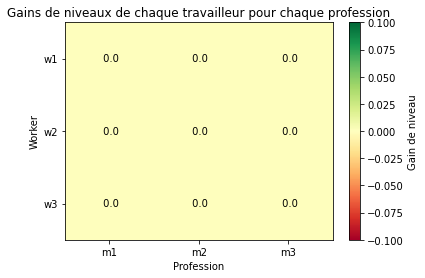

In [34]:
resume_levels_workers(s, instance)

- $w_2$ a fait toutes les taches seuls, malgrés le temps pris cela lui a permis de ne pas augmenter "sa charge cognitif" qui justement doit etre bien défini car je pense que tutorer un autre opérateur pour pouvoir diminuer le temps de réalisation peut lui procurer une charge cognitif "plus faible" ? À voir car charge cognitif est tres basse peut etre mais la charge physique est peut etre plus élevé ?

---

# III. Test des 3 objectifs

## III.A Optimisation LEXICOGRAPHIQUE

### En suivant toutes les permutations possibles des 3 objectifs

In [56]:
model = Model(instance)
s_L_S_M = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[0, 1, 2], verbose=False)
s_L_M_S = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 0, 2], verbose=False)

s_S_L_M = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[0, 2, 1], verbose=False)
s_S_M_L = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 2, 0], verbose=False)

s_M_L_S = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 0, 1], verbose=False)
s_M_S_L = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0001e-06
ici ->  4
nObjectives 4
nSolutions 4
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0001e-06
ici ->  4
nObjectives 4
nSolutions 4
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0001e-06
ici ->  4
nObjectives 4
nSolutions 7
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0001e-06
ici ->  4
nObjectives 4
nSolutions 8
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 1.0001e-06
ici ->  4
nObjectives 4
nSolutions 9
Set parameter SolFiles to value "../results/intermediat

In [50]:
x = np.zeros((6, 3)) # 6 solutions, 3 objectifs
for i, sol_curr in enumerate((s_L_S_M, s_L_M_S, s_S_L_M, s_S_M_L, s_M_L_S, s_M_S_L)):
    x[i, 0] = sol_curr.C_max
    x[i, 1] = np.sum(sol_curr.l) # ici on regarde au sens de la somme qui est l'obj - Voir solution plus équitable par la suite
    x[i, 2] = np.sum(sol_curr.cognitive_load_total) # ici on regarde au sens de la somme qui est l'obj - Voir solution plus équitable par la suite

In [57]:
print(s.objective_values)

{}


In [51]:
x

array([[109.      ,  18.      ,   0.      ],
       [109.010901,  18.      ,   0.      ],
       [ 91.      ,  20.5     ,   5.      ],
       [ 86.008601,  20.5     ,   7.      ],
       [ 86.008601,  19.5     ,   3.      ],
       [ 86.008601,  20.5     ,   7.      ]])

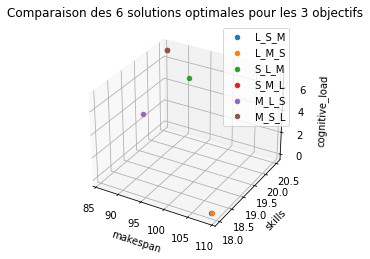

In [53]:
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("makespan")
axes.set_ylabel("skills")
axes.set_zlabel("cognitive_load")

for i in range(len(x)):
    axes.scatter(x[i,0], x[i,1], x[i,2], marker="o")


axes.set_title("Comparaison des 6 solutions optimales pour les 3 objectifs")
axes.legend(["L_S_M", "L_M_S", "S_L_M", "S_M_L", "M_L_S", "M_S_L"])
plt.show()

## Ne pas prendre en compte ce qui est apres - La suite du notebook n'est pas à jours

---

---

---

---

## Activation et désactivation de certaines contraintes pour voir leur impact sur les résultats

### #Contraintes standard

In [266]:
constraints_config = {
    "at_least_one_worker_with_level_greater_than_difficulty_of_task": False,
    "no_teaching_tasks": False,
    "no_collaboration_tasks": False,
    "no_solo_tasks": False,
    "all_collaboration_tasks": False,
    "all_solo_tasks": False,
    "constrained_makespan": False,
    "deadline_constraints_operation": False
}

#### min makespan

In [267]:
res = read_file("../data/data_temp.test")
instance = Instance()
instance.from_dictionary(res)
# print(instance)

model = Model(instance)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[0, 0, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 55.999997103619464
ici ->  1
nObjectives 1
nSolutions 3


In [ ]:
gantt_chart(s, instance, color=1, render="notebook", separate_little=True)

[(0.0, (1, 0), 4.0, 3, 1, 'alone', 3.0, 3), (3.999999999999318, (1, 1), 15.0, 1, 0, 'alone', 4.0, 2), (18.999999999998636, (1, 2), 10.0, 6, 2, 'alone', 2.0, 2), (28.999999999998636, (1, 3), 2.0, 4, 1, 'collaboratively', 3.0, 2), (30.99999999999426, (0, 0), 3.0, 0, 0, 'alone', 4.0, 1), (33.999999999994145, (1, 4), 2.0, 4, 1, 'collaboratively', 3.0, 2), (35.99999999999273, (0, 1), 5.0, 2, 1, 'alone', 3.0, 3), (40.99999999999265, (0, 2), 10.0, 6, 2, 'alone', 2.0, 2), (50.99999999999257, (0, 3), 5.0, 2, 1, 'alone', 3.0, 3)]


,Task,Start,Finish,Finish (var. f),Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w1,29.0,31.0,31.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
1,w2,0.0,4.0,4.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
2,w2,4.0,19.0,19.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
3,w2,19.0,29.0,29.0,"(2,3)",J2,alone,2.0,2,6.0,2.0
4,w2,29.0,31.0,31.0,"(2,4)",J2,collaboratively,3.0,2,4.0,1.0
5,w2,31.0,34.0,34.0,"(1,1)",J1,alone,4.0,1,0.0,0.0
6,w2,34.0,36.0,36.0,"(2,5)",J2,collaboratively,3.0,2,4.0,1.0
7,w2,36.0,41.0,41.0,"(1,2)",J1,alone,3.0,3,2.0,1.0
8,w2,41.0,51.0,51.0,"(1,3)",J1,alone,2.0,2,6.0,2.0
9,w2,51.0,56.0,56.0,"(1,4)",J1,alone,3.0,3,2.0,1.0


cognitive_load_collaboration=
[[0.  0.5 0. ]
 [0.  1.  0. ]
 [0.  0.5 0. ]]


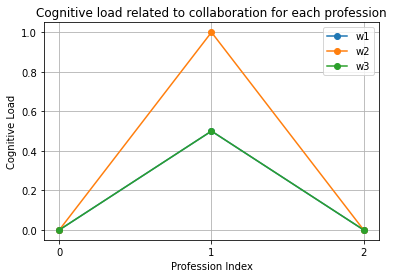

In [269]:
# plot_cognitive_load_tutors(s, instance, verbose=True)
# plot_cognitive_load_apprentis(s, instance, verbose=True)
plot_cognitive_load_collaboration(s, instance, verbose=True)
# plot_cognitive_load_total(s, instance, verbose=True)

#### Après avoir minimisé le makespan voir si on peut former des apprenti - lexicographiquement

In [271]:
res = read_file("../data/data_temp.test")
instance = Instance()
instance.from_dictionary(res)

model = Model(instance)
s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 56.0056009942994
ici ->  3
nObjectives 3
nSolutions 7


In [ ]:
gantt_chart(s, instance, color=1, render="notebook", separate_little=True)

[(0.0, (0, 0), 3.0, 0, 0, 'alone', 4.0, 1), (3.0, (1, 0), 4.0, 3, 1, 'alone', 3.0, 3), (7.0, (0, 1), 5.0, 2, 1, 'alone', 3.0, 3), (12.0, (1, 1), 15.0, 1, 0, 'alone', 4.0, 2), (27.0, (1, 2), 10.0, 6, 2, 'alone', 2.0, 2), (37.0, (0, 2), 10.0, 6, 2, 'alone', 2.0, 2), (47.0, (1, 3), 2.0, 4, 1, 'collaboratively', 3.0, 2), (49.0, (0, 3), 5.0, 2, 1, 'alone', 3.0, 3), (54.0, (1, 4), 2.0, 4, 1, 'collaboratively', 3.0, 2)]


,Task,Start,Finish,Finish (var. f),Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w1,47.0,49.0,49.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
1,w1,54.0,56.0,56.0,"(2,5)",J2,collaboratively,2.0,2,4.0,1.0
2,w2,0.0,3.0,3.0,"(1,1)",J1,alone,4.0,1,0.0,0.0
3,w2,3.0,7.0,7.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
4,w2,7.0,12.0,12.0,"(1,2)",J1,alone,3.0,3,2.0,1.0
5,w2,12.0,27.0,27.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
6,w2,27.0,37.0,37.0,"(2,3)",J2,alone,2.0,2,6.0,2.0
7,w2,37.0,47.0,47.0,"(1,3)",J1,alone,2.0,2,6.0,2.0
8,w2,47.0,49.0,49.0,"(2,4)",J2,collaboratively,3.0,2,4.0,1.0
9,w2,49.0,54.0,54.0,"(1,4)",J1,alone,3.0,3,2.0,1.0


aucune tache n'a été assignée à un apprenti

In [273]:
# plot_levels_workers(s, instance, verbose=True)
# plot_cognitive_load_tutors(s, instance, verbose=True)
# plot_cognitive_load_apprentis(s, instance, verbose=True)
# plot_cognitive_load_collaboration(s, instance, verbose=True)
# plot_cognitive_load_total(s, instance, verbose=True)

### #Maximiser skills puis le makespan lexicographiquement

In [274]:
model = Model(instance)
s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 2, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 85.008501
ici ->  3
nObjectives 3
nSolutions 5


In [ ]:
gantt_chart(s, instance, color=1, render="notebook", separate_little=True)

[(0.0, (1, 0), 4.0, 3, 1, 'alone', 3.0, 3), (4.0, (1, 1), 21.0, 1, 0, 'learning (tutor)', 4.0, 2), (25.0, (0, 1), 8.0, 2, 1, 'learning (tutor)', 3.0, 3), (33.0, (0, 2), 20.0, 6, 2, 'learning (tutor)', 2.0, 2), (53.0, (1, 2), 20.0, 6, 2, 'learning (tutor)', 2.0, 2), (73.0, (1, 3), 2.0, 4, 1, 'collaboratively', 3.0, 2), (75.0, (0, 3), 8.0, 2, 1, 'learning (tutor)', 3.0, 3), (83.0, (1, 4), 2.0, 4, 1, 'collaboratively', 3.0, 2)]


,Task,Start,Finish,Finish (var. f),Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w1,73.0,75.0,75.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
1,w1,83.0,85.0,85.0,"(2,5)",J2,collaboratively,2.0,2,4.0,1.0
2,w2,0.0,4.0,4.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
3,w2,4.0,25.0,25.0,"(2,2)",J2,learning (tutor),4.0,2,1.0,0.0
4,w2,25.0,33.0,33.0,"(1,2)",J1,learning (tutor),3.0,3,2.0,1.0
5,w2,33.0,53.0,53.0,"(1,3)",J1,learning (tutor),2.0,2,6.0,2.0
6,w2,53.0,73.0,73.0,"(2,3)",J2,learning (tutor),2.0,2,6.0,2.0
7,w2,73.0,75.0,75.0,"(2,4)",J2,collaboratively,3.0,2,4.0,1.0
8,w2,75.0,83.0,83.0,"(1,4)",J1,learning (tutor),3.0,3,2.0,1.0
9,w2,83.0,85.0,85.0,"(2,5)",J2,collaboratively,3.0,2,4.0,1.0


des taches ont été assignées à des apprentis

levels_workers=
[[[2.  2.  1. ]
  [2.  2.  1. ]]

 [[4.  3.  2. ]
  [4.  3.  2. ]]

 [[1.  2.  1. ]
  [1.5 3.  2. ]]]


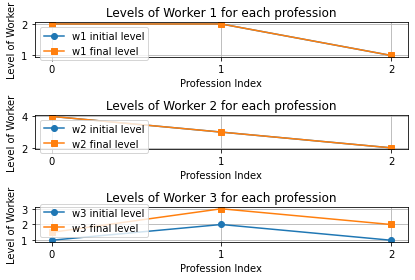

cognitive_load_tutors=
[[0.  0.  0. ]
 [0.7 1.4 1.4]
 [0.  0.  0. ]]


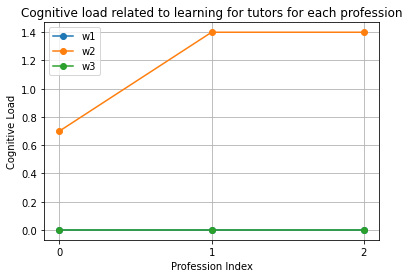

cognitive_load_apprentis=
[[0.  0.  0. ]
 [0.  0.  0. ]
 [0.3 0.6 0.6]]


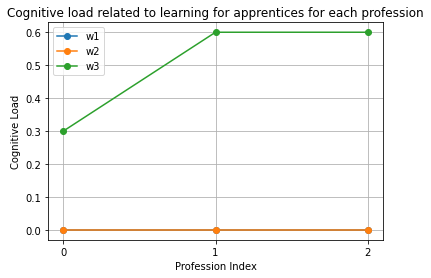

cognitive_load_collaboration=
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]


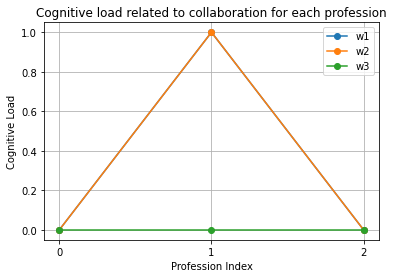

cognitive_load_total=
[[0.  1.  0. ]
 [0.7 2.4 1.4]
 [0.3 0.6 0.6]]


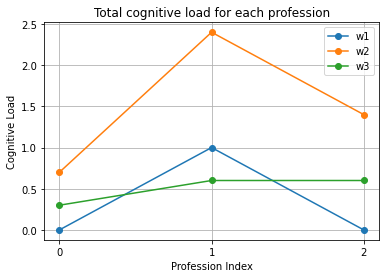

In [276]:
plot_levels_workers(s, instance, verbose=True)
plot_cognitive_load_tutors(s, instance, verbose=True)
plot_cognitive_load_apprentis(s, instance, verbose=True)
plot_cognitive_load_collaboration(s, instance, verbose=True)
plot_cognitive_load_total(s, instance, verbose=True)

In [278]:
read_file("../data/data_temp.test")
instance = Instance()
instance.from_dictionary(res)
model = Model(instance)
s = model.solve(objective="lexicographic", weight=[0.5, 0.5, 0], priority=[1, 0, 2], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.006201
ici ->  3
nObjectives 3
nSolutions 3


In [ ]:
gantt_chart(s, instance, color=1, render="notebook", separate_little=True)

[(0.0, (0, 0), 3.0, 0, 0, 'alone', 4.0, 1), (3.0, (1, 0), 4.0, 3, 1, 'alone', 3.0, 3), (7.0, (0, 1), 5.0, 2, 1, 'alone', 3.0, 3), (12.0, (0, 2), 10.0, 6, 2, 'alone', 2.0, 2), (22.0, (0, 3), 5.0, 2, 1, 'alone', 3.0, 3), (27.0, (1, 1), 15.0, 1, 0, 'alone', 4.0, 2), (42.0, (1, 2), 10.0, 6, 2, 'alone', 2.0, 2), (52.0, (1, 3), 5.0, 4, 1, 'alone', 3.0, 2), (57.0, (1, 4), 5.0, 4, 1, 'alone', 3.0, 2)]


,Task,Start,Finish,Finish (var. f),Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w2,0.0,3.0,3.0,"(1,1)",J1,alone,4.0,1,0.0,0.0
1,w2,3.0,7.0,7.0,"(2,1)",J2,alone,3.0,3,3.0,1.0
2,w2,7.0,12.0,12.0,"(1,2)",J1,alone,3.0,3,2.0,1.0
3,w2,12.0,22.0,22.0,"(1,3)",J1,alone,2.0,2,6.0,2.0
4,w2,22.0,27.0,27.0,"(1,4)",J1,alone,3.0,3,2.0,1.0
5,w2,27.0,42.0,42.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
6,w2,42.0,52.0,52.0,"(2,3)",J2,alone,2.0,2,6.0,2.0
7,w2,52.0,57.0,57.0,"(2,4)",J2,alone,3.0,2,4.0,1.0
8,w2,57.0,62.0,62.0,"(2,5)",J2,alone,3.0,2,4.0,1.0


# ###Optimisation LEXICOGRAPHIQUE

### En suivant toutes les permutations possibles des 3 objectifs

In [280]:
s_L_S_M = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[0, 1, 2], verbose=False)
s_L_M_S = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 0, 2], verbose=False)

s_S_L_M = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[0, 2, 1], verbose=False)
s_S_M_L = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 2, 0], verbose=False)

s_M_L_S = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 0, 1], verbose=False)
s_M_S_L = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.0
ici ->  3
nObjectives 3
nSolutions 3
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.006201
ici ->  3
nObjectives 3
nSolutions 3
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 91.0
ici ->  3
nObjectives 3
nSolutions 5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 85.008501
ici ->  3
nObjectives 3
nSolutions 5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 56.0056009942994
ici ->  3
nObjectives 3
nSolutions 6
Set parameter SolFiles to value "../results/intermediate_soluti

In [281]:
sol = []
for i in (s_L_S_M, s_L_M_S, s_S_L_M, s_S_M_L, s_M_L_S, s_M_S_L):
    sol.append(i.objective_values)

x = np.zeros((len(sol), 3))
for i in range(len(sol)):
    for j in range(3):
        x[i][j] = sol[i][j]
x

array([[ 62.        , -18.        ,   0.        ],
       [ 62.006201  , -18.        ,   0.        ],
       [ 91.        , -20.5       ,   5.        ],
       [ 85.008501  , -20.5       ,   7.        ],
       [ 56.00560099, -18.        ,   2.        ],
       [ 56.00560099, -18.        ,   2.        ]])

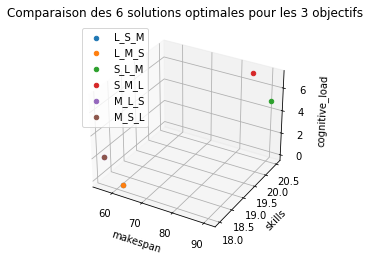

In [282]:
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("makespan")
axes.set_ylabel("skills")
axes.set_zlabel("cognitive_load")

for i in range(len(x)):
    axes.scatter(x[i,0], - x[i,1], x[i,2], marker="o")


axes.set_title("Comparaison des 6 solutions optimales pour les 3 objectifs")
axes.legend(["L_S_M", "L_M_S", "S_L_M", "S_M_L", "M_L_S", "M_S_L"])
plt.show()

### Génération instance aléatoire

In [323]:
instance_random = Instance()
instance_random.from_random(seed=42)
print(instance_random) 


 ===== Start of Instance: =====
Number of jobs: 4
Number of professions: 3
Number of tasks per profession: [2 2 3]
Max number of operations per Jobs: 7
Total number of tasks: 7
Total number of workers: 7
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2}
Worker levels: shape=(7, 3)
 [[2 2 2]
 [1 2 1]
 [2 4 4]
 [3 4 3]
 [4 1 4]
 [3 3 2]
 [1 4 2]]
Job difficulties: shape= (4,)
[2 4 2 4]
Task difficulties: shape= (7,)
[1 1 3 2 4 1 4]
Task processing times: shape= (7, 3)
[[ 7.          8.44322744  5.33664751]
 [19.         28.32848616 13.60347768]
 [11.         15.94706071  7.10176027]
 [11.         13.90071907  8.86519092]
 [ 4.          5.01818996  2.27898772]
 [ 8.         10.04017082 -1.        ]
 [ 3.          3.87381802  2.04954276]]
Jobs structure: len= 4
Job 0 : 	O_(0,0) 	O_(0,1) 	O_(0,2) 	O_(0,3) 	O_(0,4) 	O_(0,5) 
Job 1 : 	O_(1,0) 	O_(1,1) 	O_(1,2) 	O_(1,3) 	O_(1,4) 	O_(1,5) 
Job 2 : 	O_(2,0) 	O_(2,1) 	O_(2,2) 	O_(2,3) 
Job 3 : 	O_(3,0) 	O_(3,1) 	O_(3,2) 	O_(

## MIN makespan

In [327]:
model = Model(instance_random)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[0, 0, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.20695535420012
ici ->  1
nObjectives 1
nSolutions 9


In [ ]:
gantt_chart(s, instance_random, color=3, render="notebook", separate_little=True)

[(16.89200797931214, (1, 3), 13.603477677100098, 1, 0, 'collaboratively', 1, 1)]


,Task,Start,Finish,Finish (var. f),Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w1,0.000000,11.000000,11.000000,"(1,1)",J1,alone,2,2,3.0,1.0
1,w1,11.000000,24.603478,24.603478,"(1,2)",J1,collaboratively,2,1,1.0,0.0
2,w1,24.603478,32.603478,32.603478,"(1,3)",J1,alone,2,1,5.0,2.0
3,w1,32.603478,40.603478,40.603478,"(1,4)",J1,alone,2,1,5.0,2.0
4,w1,40.603478,48.603478,48.603478,"(1,5)",J1,alone,2,1,5.0,2.0
5,w1,48.603478,62.206955,62.206955,"(1,6)",J1,collaboratively,2,1,1.0,0.0
6,w2,16.892008,30.495486,30.495486,"(2,4)",J2,collaboratively,1,1,1.0,0.0
7,w3,8.000000,13.018190,13.018190,"(2,2)",J2,learning (tutor),4,4,4.0,2.0
8,w3,13.018190,32.018190,32.018190,"(3,1)",J3,alone,2,1,1.0,0.0
9,w3,32.018190,40.018190,40.018190,"(3,2)",J3,alone,4,1,5.0,2.0


### On voit que des taches on été fait en teaching

## Normalement si j'interdis les taches de teaching, alors aucune tache ne doit être assignée à un apprenti

In [330]:
constraints_config = {"no_teaching_tasks": True}
model = Model(instance_random)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[0, 0, 0], constraints_config=constraints_config, verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 75.6520307145533
ici ->  1
nObjectives 1
nSolutions 9


In [ ]:
gantt_chart(s, instance_random, color=3, render="notebook", separate_little=True)

[(25.378046007694095, (1, 3), 13.603477677100102, 1, 0, 'collaboratively', 1, 1), (66.78683979358021, (1, 5), 8.865190920973092, 3, 1, 'collaboratively', 2, 2)]


,Task,Start,Finish,Finish (var. f),Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w1,0.000000,11.000000,11.000000,"(1,1)",J1,alone,2,2,3.0,1.0
1,w1,11.000000,24.603478,24.603478,"(1,2)",J1,collaboratively,2,1,1.0,0.0
2,w1,24.603478,32.603478,32.603478,"(1,3)",J1,alone,2,1,5.0,2.0
3,w1,32.603478,40.603478,40.603478,"(1,4)",J1,alone,2,1,5.0,2.0
4,w1,40.603478,48.603478,48.603478,"(1,5)",J1,alone,2,1,5.0,2.0
5,w1,48.999038,62.602515,62.602515,"(1,6)",J1,collaboratively,2,1,1.0,0.0
6,w2,25.378046,38.981524,38.981524,"(2,4)",J2,collaboratively,1,1,1.0,0.0
7,w2,66.786840,75.652031,75.652031,"(2,6)",J2,collaboratively,2,2,3.0,1.0
8,w3,0.000045,3.000045,3.000045,"(4,1)",J4,alone,4,4,6.0,2.0
9,w3,3.000045,11.000045,11.000045,"(4,2)",J4,alone,4,1,5.0,2.0


In [324]:
model = Model(instance_random)
s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.21317704972073
ici ->  3
nObjectives 3
nSolutions 6


In [ ]:
gantt_chart(s, instance_random, color=0, render="notebook", separate_little=True)

[]


,Task,Start,Finish,Finish (var. f),Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w1,0.000000,8.000000,8.000000,"(2,1)",J2,alone,2,1,5.0,2.0
1,w1,8.000000,13.018190,13.018190,"(2,2)",J2,learning (apprentice),2,4,4.0,2.0
2,w1,14.735881,18.609699,18.609699,"(2,3)",J2,learning (apprentice),2,4,6.0,2.0
3,w1,18.609699,32.213177,32.213177,"(2,4)",J2,collaboratively,2,1,1.0,0.0
4,w1,32.213177,51.213177,51.213177,"(2,5)",J2,alone,2,1,1.0,0.0
5,w1,51.213177,62.213177,62.213177,"(2,6)",J2,alone,2,2,3.0,1.0
6,w3,8.000000,13.018190,13.018190,"(2,2)",J2,learning (tutor),4,4,4.0,2.0
7,w3,18.609699,32.213177,32.213177,"(2,4)",J2,collaboratively,2,1,1.0,0.0
8,w3,48.609699,62.213177,62.213177,"(1,6)",J1,collaboratively,2,1,1.0,0.0
9,w4,11.000000,24.603478,24.603478,"(1,2)",J1,collaboratively,3,1,1.0,0.0


levels_workers=
[[[2.  2.  2. ]
  [2.  2.  3. ]]

 [[1.  2.  1. ]
  [1.  2.  1. ]]

 [[2.  4.  4. ]
  [2.  4.  4. ]]

 [[3.  4.  3. ]
  [3.  4.  3. ]]

 [[4.  1.  4. ]
  [4.  2.  4. ]]

 [[3.  3.  2. ]
  [3.  3.  2. ]]

 [[1.  4.  2. ]
  [1.  4.  2.5]]]


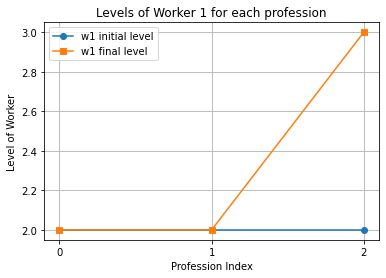

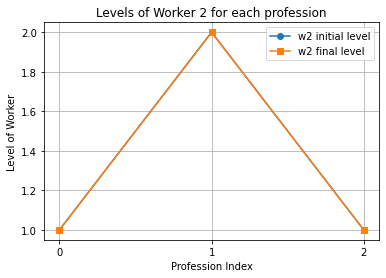

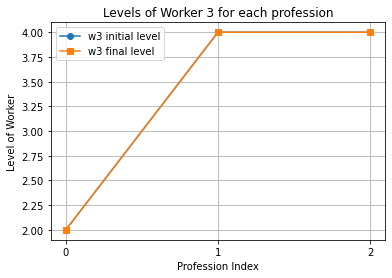

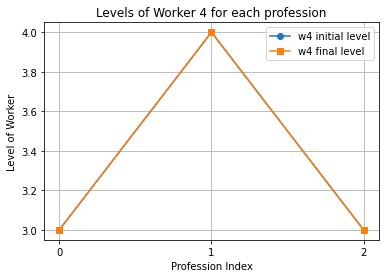

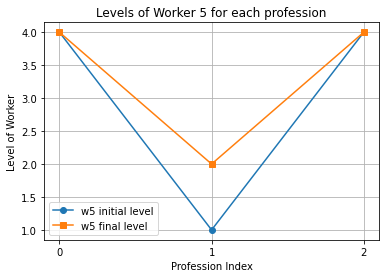

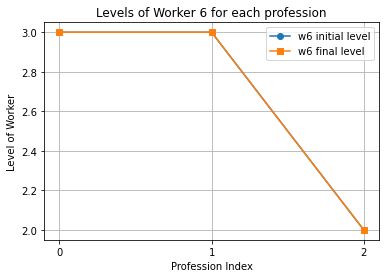

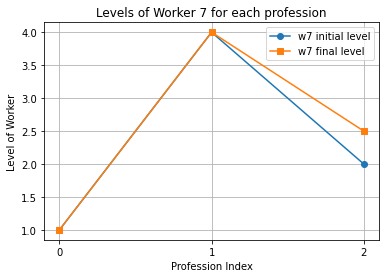

cognitive_load_tutors=
[[0.  0.  0. ]
 [0.  0.  0. ]
 [0.  0.  0.7]
 [0.  0.7 0. ]
 [0.  0.  1.4]
 [0.  0.  0. ]
 [0.  0.7 0. ]]


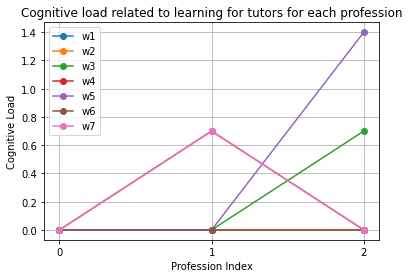

cognitive_load_apprentis=
[[0.  0.  0.6]
 [0.  0.  0. ]
 [0.  0.  0. ]
 [0.  0.  0. ]
 [0.  0.6 0. ]
 [0.  0.  0. ]
 [0.  0.  0.3]]


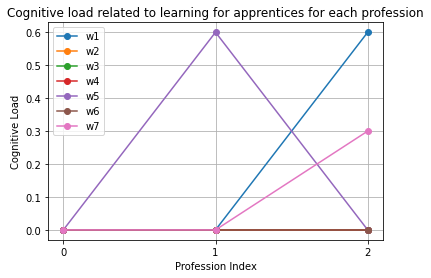

cognitive_load_collaboration=
[[0.5 0.  0. ]
 [0.  0.  0. ]
 [1.  0.  0. ]
 [0.5 0.  0. ]
 [0.  0.  0. ]
 [1.  0.  0. ]
 [0.  0.  0. ]]


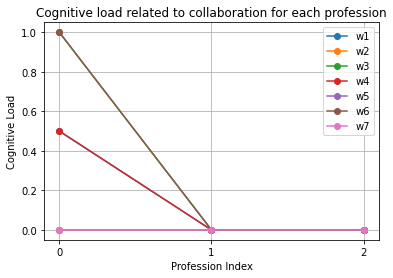

cognitive_load_total=
[[0.5 0.  0.6]
 [0.  0.  0. ]
 [1.  0.  0.7]
 [0.5 0.7 0. ]
 [0.  0.6 1.4]
 [1.  0.  0. ]
 [0.  0.7 0.3]]


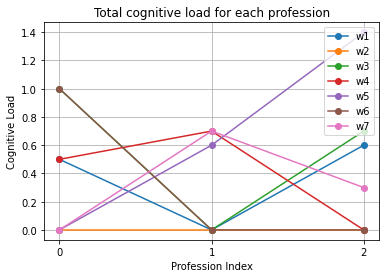

cognitive_load_total_per_worker=
[1.1 0.  1.7 1.2 2.  1.  1. ]


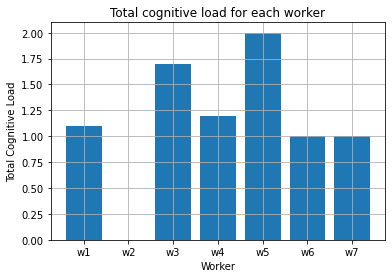

In [326]:
plot_levels_workers(s, instance_random, verbose=True)
plot_cognitive_load_tutors(s, instance_random, verbose=True)
plot_cognitive_load_apprentis(s, instance_random, verbose=True)
plot_cognitive_load_collaboration(s, instance_random, verbose=True)
plot_cognitive_load_total(s, instance_random, verbose=True)
bars_cognitive_load_total(s, instance_random, verbose=True)

### #Lancer le PL avec des poids aléatoires pour les 3 objectifs et voir les résultats obtenus

In [319]:
opt_makespan = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)
opt_skills = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 2, 0], verbose=False)
opt_cognitive_load = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 0, 2], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.21317704972073
ici ->  3
nObjectives 3
nSolutions 6
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.213177049722134
ici ->  3
nObjectives 3
nSolutions 10
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 96.0096009902981
ici ->  3
nObjectives 3
nSolutions 4


In [320]:
print(opt_makespan.objective_values)
print(opt_skills.objective_values)
print(opt_cognitive_load.objective_values)

{0: 62.21317704972073, 1: -56.5, 2: 8.0}
{0: 62.213177049722134, 1: -56.5, 2: 8.0}
{0: 96.0096009902981, 1: -54.0, 2: 0.0}


In [ ]:
NB_ITER = 5
model = Model(instance_random)
sol = []
for i in range(NB_ITER):
    weight = np.random.rand(3)
    s = model.solve(objective="lexicographic", weight=weight, priority=[0, 0, 0], verbose=False)
    sol.append(s.objective_values)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.20695535419543
ici ->  3
nObjectives 3
nSolutions 10
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.20695535419543
ici ->  3
nObjectives 3
nSolutions 10
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.20695535419543
ici ->  3
nObjectives 3
nSolutions 10
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.20695535419543
ici ->  3
nObjectives 3
nSolutions 10
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 62.20695535419543
ici ->  3
nObjectives 3
nSolutions 10


In [322]:
sol

[{0: 62.20695535419543, 1: -54.5, 2: 4.0},
 {0: 62.20695535419543, 1: -54.5, 2: 4.0},
 {0: 62.20695535419543, 1: -54.5, 2: 4.0},
 {0: 62.20695535419543, 1: -54.5, 2: 4.0},
 {0: 62.20695535419543, 1: -54.5, 2: 4.0}]